# Poledna (2023), on the SPARQL engine

The base macro ABM of Poledna, Miess, Hommes & Rabitsch (2023), *Economic forecasting with an
agent-based model*, European Economic Review 151, 104306 — run through
`skabm.simulation.RDFSimulator`.

Seven SPARQL rules make one quarter: firms choose output (eq. 5 + 12) and set prices (eq. 8),
households refresh income (eq. 49) and consume (eqs. 40 + 50), the goods market clears
(eqs. 1-2 + 27 + 31), government spends (eq. 51), and the central bank sets its rate by a
Taylor rule (eq. 69). The rules live in `skabm/behaviour/`; this notebook is only the data
around them.

Two companion notebooks extend this one: `02_interbank_contagion.ipynb` adds a banking layer
that propagates distress to a fixed point, and `03_sac_learning.ipynb` opens up the learned
expectations this run already uses.

In [1]:
import matplotlib.pyplot as plt
import polars as pl
import polars_random as pr

from skabm.behaviour.params import poledna_params
from skabm.simulation import RDFSimulator

N_FIRMS, N_HOUSEHOLDS, N_GOV, N_FOREIGN = 50, 500, 3, 10

pr.set_random_seed(0)
firms = (
    pl.DataFrame({
        "id": [f"firm_{i}" for i in range(N_FIRMS)],
        "size": pr.normal(100.0, 30.0, size=N_FIRMS).clip(10, None).round(0),
        "alpha": 1.0, "w_bar": 1.0, "tech_share": 0.1,
        "price": 1.0, "margin": 0.2, "liquidity": 0.0,
    })
    .with_columns(pl.col("size").cast(pl.Float64))
    .with_columns(output=pl.col("size") * pl.col("alpha") * 0.9)
    .with_columns(profit=0.2 * pl.col("output"))
)

pr.set_random_seed(1)
households = pl.DataFrame({
    "id": [f"hh_{i}" for i in range(N_HOUSEHOLDS)],
    "psi": 0.9,
    "income": (pr.uniform(0.5, 2.0, size=N_HOUSEHOLDS) * 10.0).round(2),
})

governments = pl.DataFrame({
    "id": [f"gov_{i}" for i in range(N_GOV)],
    "budget": [50.0] * N_GOV, "tax_rate": 0.2134,
})
foreign_firms = pl.DataFrame({
    "id": [f"foreign_{i}" for i in range(N_FOREIGN)], "demand_size": [20.0] * N_FOREIGN,
})
central_bank = pl.DataFrame({
    "id": ["central_bank"], "policy_rate": [0.009], "inflation_target": [0.005],
    "prev_output": [float(firms["output"].sum())], "prev_price": [1.0],
})

populations = dict(
    Firm=firms, Household=households, Government=governments,
    ForeignFirm=foreign_firms, CentralBank=central_bank,
)

params = {
    **poledna_params,
    "total_deposits": 2000.0,
    "firm_ownership_ratio": N_FIRMS / N_HOUSEHOLDS,
    # Expectations are learned from the model's own history, not parameterised.
    # A cold run starts with an empty history, so the opening forecast is zero
    # and a fully deterministic economy would sit still; the shocks below are
    # what give the AR(1) something to estimate.  See 03_sac_learning.ipynb.
    "growth_sigma": 0.02,
    "inflation_sigma": 0.01,
}
firms.head(3)

id,size,alpha,w_bar,tech_share,price,margin,liquidity,output,profit
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""firm_0""",85.0,1.0,1.0,0.1,1.0,0.2,0.0,76.5,15.3
"""firm_1""",137.0,1.0,1.0,0.1,1.0,0.2,0.0,123.3,24.66
"""firm_2""",60.0,1.0,1.0,0.1,1.0,0.2,0.0,54.0,10.8


## Run

`fit_iter` yields one raw per-agent state frame per tick. The simulator does no aggregation, so
GDP and the price level are ordinary polars expressions on the caller's side.

In [2]:
sim = RDFSimulator(params=params, n_periods=16, random_seed=0)

path = []
for t, state in enumerate(sim.fit_iter(**populations)):
    active = state.drop_nulls("output")
    path.append({
        "t": t,
        "gdp": (active["price"] * active["output"] * (1 - active["tech_share"])).sum(),
        "price_level": active["price"].mean(),
        "policy_rate": state["policy_rate"].drop_nulls().item(),
        "wealth": state["wealth"].drop_nulls().sum(),
    })

path = pl.DataFrame(path)
path.head()

t,gdp,price_level,policy_rate,wealth
i64,f64,f64,f64,f64
0,4169.748321,0.998439,0.008523,2386.53146
1,4149.175821,0.99559,0.007634,2970.092162
2,4166.036594,0.993951,0.007544,3407.08517
3,4117.715002,0.989002,0.006191,3738.777314
4,4135.354774,0.985763,0.006382,3968.371447


## The quarterly path

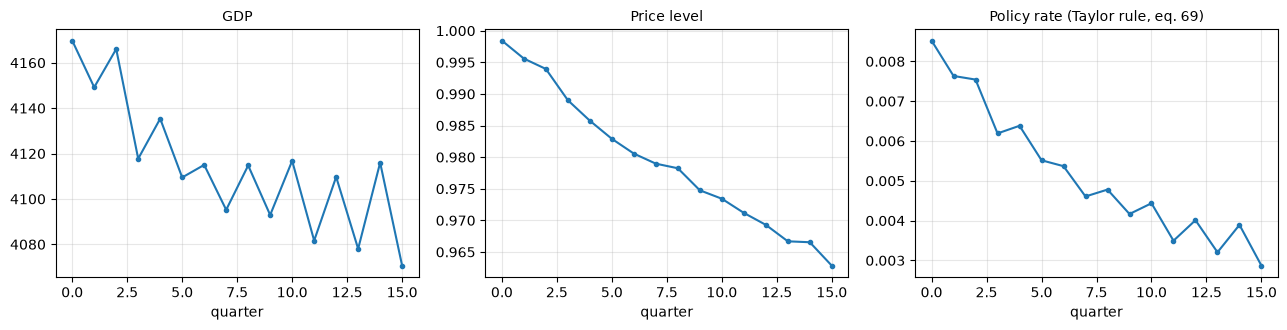

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, col, title in zip(
    axes,
    ["gdp", "price_level", "policy_rate"],
    ["GDP", "Price level", "Policy rate (Taylor rule, eq. 69)"],
):
    ax.plot(path["t"], path[col], marker="o", ms=3)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("quarter")
    ax.grid(alpha=0.3)
fig.tight_layout()

## The fitted artifact is a graph

`sim.model_` is a plain maplib `Model` after the fit: query it, intervene on it, serialize it, or
open `explore()` on it. Here are the provenance triples each rule template carries — every
behaviour is a node linked to the agent class it governs and to its source in the paper.

In [4]:
sim.model_.query("""
PREFIX ex: <http://example.net/skabm#>
PREFIX dct: <http://purl.org/dc/terms/>
SELECT ?agent_class ?behaviour ?source WHERE {
    ?agent_class ex:behaviour ?behaviour .
    OPTIONAL { ?behaviour dct:source ?source }
}
ORDER BY ?agent_class
""")

agent_class,behaviour,source
str,str,str
"""<http://example.net/skabm#Firm…","""<http://example.net/skabm#firm…","""Poledna et al. (2023), Europea…"
"""<http://example.net/skabm#Firm…","""<http://example.net/skabm#firm…","""Poledna et al. (2023), Europea…"
"""<http://example.net/skabm#Firm…","""<http://example.net/skabm#firm…","""Poledna et al. (2023), Europea…"
"""<http://example.net/skabm#Firm…","""<http://example.net/skabm#firm…","""Poledna et al. (2023), Europea…"


## Intervention, then resume

A do-calculus style intervention is just an update against `model_`, and `warm_start=True` keeps
ticking the world that results — no rebuild, no re-mapping. Here every firm's price is pinned to
1.0 mid-run, and the simulation carries on from there.

In [5]:
sim.model_.update("""
PREFIX ex: <http://example.net/skabm#>
PREFIX def: <urn:maplib_default:>
DELETE { ?f def:price ?p0 }
INSERT { ?f def:price 1e0 }
WHERE  { ?f a ex:Firm ; def:price ?p0 }
""")

sim.warm_start = True
after = list(sim.fit_iter())
print("price level just after the intervention:", after[0].drop_nulls("price")["price"].mean())
print("price level 16 quarters later          :", after[-1].drop_nulls("price")["price"].mean())

price level just after the intervention: 0.9964510054551323
price level 16 quarters later          : 0.9891558113267874
